In [1]:
import os
import numpy as np
from pathlib import Path
from matplotlib import rc
from matplotlib import font_manager
import matplotlib.pyplot as plt
import cortex as cx
from prf_expect.utils import io
from prf_expect.utils.viz import desaturate_palette, sample_cmap, cm_to_inch

In [2]:
cwd = os.getcwd()
figure_result_dir = Path(cwd).parent / "figures"
subjects = ["sub-001", "sub-002", "sub-004", "sub-005", "sub-007", "sub-009", "sub-012"]
font_dirs = [Path(cwd).parent.parent.parent / "arial"]
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

rc("pdf", fonttype=42, use14corefonts=False)
rc("axes", linewidth=0.5)
rc("font", **{"family": "Arial"})
rc("text", usetex=False)
rc("xtick", labelsize=6)
rc("ytick", labelsize=6)
rc("axes", labelsize=7)
rc("legend", fontsize=6)

plt.rcParams["xtick.major.width"] = 0.5
plt.rcParams["ytick.major.width"] = 0.5
plt.rcParams["xtick.major.size"] = 2
plt.rcParams["ytick.major.size"] = 2
plt.rcParams["xtick.minor.width"] = 0.5
plt.rcParams["ytick.minor.width"] = 0.5
plt.rcParams["xtick.minor.size"] = 1
plt.rcParams["ytick.minor.size"] = 1

# set up figure parameters
markeredgecolor = ".4"
bar_linewidth = 0.5
bar_alpha = 0.7
xticks_rotation = 45
marker = "s"
marker_edge_width = 0.5
markersize = 3 / 2.54
errorbar_linewidth = 0.5
errorbar_capsize = 2 / 2.54
errorbar_capthick = 0.5

In [3]:
settings = io.load_settings()
data_dir = Path(settings['general']['data_dir'], "data")

Loading settings from /Users/dionysus/Library/CloudStorage/OneDrive-Personal/Workbench/pRF_expect_pub/pRF_expect_analysis/prf_expect/settings.yml


In [4]:
surprise_analysis_type = 'TRMI-type1'
beta_omits = []
beta_spars = []
TRMIs = []
for subject in subjects:
    analysis_result_dir = Path(data_dir) / f"derivatives/prf_data/{subject}/ses-1/{surprise_analysis_type}"
    analysis_result_dir = Path(analysis_result_dir)
    if surprise_analysis_type == 'TRMI-type1':
        beta_omit_fn = analysis_result_dir / f"{subject}_ses-1_space-fsaverage_surprise-viol_beta_omitdm.npy"
        beta_omit_sub = np.load(beta_omit_fn, allow_pickle=True)
        beta_omits.append(beta_omit_sub)
        beta_spar_fn = analysis_result_dir / f"{subject}_ses-1_space-fsaverage_surprise-viol_beta_sparsedm.npy"
        beta_spar_sub = np.load(beta_spar_fn, allow_pickle=True)
        beta_spars.append(beta_spar_sub)
        TRMI = np.load(analysis_result_dir / f"{subject}_ses-1_space-fsaverage_surprise-TRMI.npy", allow_pickle=True)
        TRMIs.append(TRMI)
    if surprise_analysis_type == 'TRMI-type2':
        beta_omit_fn = analysis_result_dir / f"{subject}_ses-1_space-fsaverage_surprise-omit_beta_omitdm.npy"
        beta_omit_sub = np.load(beta_omit_fn, allow_pickle=True)
        beta_omits.append(beta_omit_sub)
        beta_spar_fn = analysis_result_dir / f"{subject}_ses-1_space-fsaverage_surprise-viol_beta_sparsedm.npy"
        beta_spar_sub = np.load(beta_spar_fn, allow_pickle=True)
        beta_spars.append(beta_spar_sub)
        TRMI = np.load(analysis_result_dir / f"{subject}_ses-1_space-fsaverage_surprise-TRMI.npy", allow_pickle=True)
        TRMIs.append(TRMI)
    if surprise_analysis_type == 'TRMI-type3':
        beta_omit_fn = analysis_result_dir / f"{subject}_ses-1_space-fsaverage_surprise-omit_beta_omitdm.npy"
        beta_omit_sub = np.load(beta_omit_fn, allow_pickle=True)
        beta_omits.append(beta_omit_sub)
        beta_spar_fn = analysis_result_dir / f"{subject}_ses-1_space-fsaverage_surprise-spar_beta_spardm.npy"
        beta_spar_sub = np.load(beta_spar_fn, allow_pickle=True)
        beta_spars.append(beta_spar_sub)
        TRMI = np.load(analysis_result_dir / f"{subject}_ses-1_space-fsaverage_surprise-TRMI.npy", allow_pickle=True)
        TRMIs.append(TRMI)
    if surprise_analysis_type == 'TRMI-type4':
        beta_omit_fn = analysis_result_dir / f"{subject}_ses-1_space-fsaverage_surprise-viol_beta_omitdm.npy"
        beta_omit_sub = np.load(beta_omit_fn, allow_pickle=True)
        beta_omits.append(beta_omit_sub)
        beta_spar_fn = analysis_result_dir / f"{subject}_ses-1_space-fsaverage_surprise-spar_beta_spardm.npy"
        beta_spar_sub = np.load(beta_spar_fn, allow_pickle=True)
        beta_spars.append(beta_spar_sub)
        TRMI = np.load(analysis_result_dir / f"{subject}_ses-1_space-fsaverage_surprise-TRMI.npy", allow_pickle=True)
        TRMIs.append(TRMI)

beta_omits = np.array(beta_omits)
beta_omits[np.isnan(beta_omits)] = 0
beta_omits[np.isinf(beta_omits)] = 0

beta_spars = np.array(beta_spars)
beta_spars[np.isnan(beta_spars)] = 0
beta_spars[np.isinf(beta_spars)] = 0


In [5]:
roi_verts = cx.get_roi_verts('fsaverage', ('V1',))
roi_indices = roi_verts["V1"]
nr_best_voxels = 200

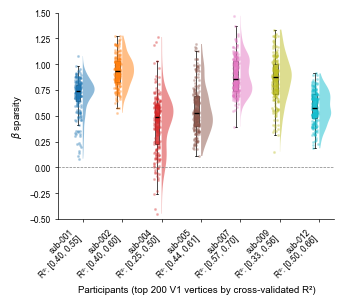

In [6]:
# plot the distribution of surprise ratios for all subjects in one figure
fig, ax = plt.subplots(figsize=cm_to_inch(9, 8))

n_subs = len(subjects)
positions = np.arange(n_subs)
sub_colors = sample_cmap('tab10', n_subs)
rsq_all_subs = []

for i, (sub, sr) in enumerate(zip(subjects, beta_spars)):
    analysis_result_dir = Path(data_dir) / f"derivatives/prf_data/{sub}/ses-1/{surprise_analysis_type}"
    fn = f"{sub}_ses-1_space-fsaverage_surprise-viol_rsq.npy"
    rsq_fn = analysis_result_dir / fn
    rsq_sub = np.load(rsq_fn, allow_pickle=True)
    # nans and infs should have been handled during data loading, but just in case:
    rsq_sub[np.isnan(rsq_sub)] = 0
    rsq_sub[np.isinf(rsq_sub)] = 0
    rsq_all_subs.append(rsq_sub)

    # top voxels: V1 mask then highest R²
    rsq_v1 = rsq_sub[roi_indices]
    best_idx_local = np.argsort(rsq_v1)[::-1][:nr_best_voxels]
    best_voxel_indices = roi_indices[best_idx_local]
    valid = sr[best_voxel_indices]
    # valid = valid[(~np.isnan(valid)) & (rsq_sub[best_voxel_indices] >= 0.1)]
    pos = positions[i]

    # Half-violin (right side only)
    parts = ax.violinplot(valid, positions=[pos], showextrema=False, widths=0.6)
    for pc in parts['bodies']:
        m = np.mean(pc.get_paths()[0].vertices[:, 0])
        pc.get_paths()[0].vertices[:, 0] = np.clip(
            pc.get_paths()[0].vertices[:, 0], m, np.inf)
        pc.set_facecolor(sub_colors[i])
        pc.set_edgecolor('none')
        pc.set_alpha(0.5)

    # Box plot (narrow, left side)
    bp = ax.boxplot(valid, positions=[pos - 0.12], widths=0.12,
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color='k', linewidth=1),
                    whiskerprops=dict(linewidth=0.5),
                    capprops=dict(linewidth=0.5),
                    boxprops=dict(facecolor=sub_colors[i], edgecolor='k',
                                linewidth=0.5, alpha=0.8))

    # Jittered strip plot (left side)
    jitter = np.random.default_rng(42).uniform(-0.08, 0.08, size=len(valid))
    ax.scatter(pos - 0.12 + jitter, valid, s=1.5, color=sub_colors[i],
            alpha=0.25, zorder=2, rasterized=True)

# Build x-tick labels with R² range
xlabels = []
for i, sub in enumerate(subjects):
    rsq = rsq_all_subs[i]
    rsq = rsq[roi_indices][np.argsort(rsq[roi_indices])[::-1][:nr_best_voxels]]
    xlabels.append(f"{sub}\nR²: [{rsq.min():.2f}, {rsq.max():.2f}]")

ax.set_ylim(-0.5, 1.5)
ax.set_xticks(positions)
ax.set_xticklabels(xlabels, rotation=xticks_rotation, ha='right')
ax.set_ylabel('$\\beta$ sparsity')
ax.set_xlabel('Participants (top 200 V1 vertices by cross-validated R²)')
ax.axhline(0, color='gray', ls='--', lw=0.5)
# ax.set_title('Distribution of TRMI across subjects', fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()
plt.show()
fig.savefig(figure_result_dir / f"group_analysis-{surprise_analysis_type}_space-fsaverage_desc-prf_viz_v1_hq-vertex_beta_sparsity-crossvalidatedrsq.pdf", dpi=600, bbox_inches='tight')

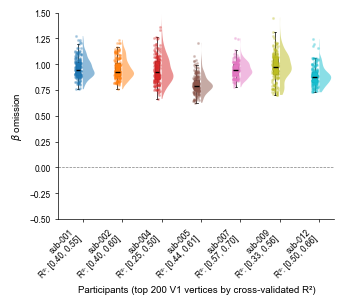

In [7]:
# plot the distribution of surprise ratios for all subjects in one figure
fig, ax = plt.subplots(figsize=cm_to_inch(9, 8))

n_subs = len(subjects)
positions = np.arange(n_subs)
sub_colors = sample_cmap('tab10', n_subs)
rsq_all_subs = []

for i, (sub, sr) in enumerate(zip(subjects, beta_omits)):
    analysis_result_dir = Path(data_dir) / f"derivatives/prf_data/{sub}/ses-1/{surprise_analysis_type}"
    fn = f"{sub}_ses-1_space-fsaverage_surprise-viol_rsq.npy"
    rsq_fn = analysis_result_dir / fn
    rsq_sub = np.load(rsq_fn, allow_pickle=True)
    # nans and infs should have been handled during data loading, but just in case:
    rsq_sub[np.isnan(rsq_sub)] = 0
    rsq_sub[np.isinf(rsq_sub)] = 0
    rsq_all_subs.append(rsq_sub)

    # top voxels: V1 mask then highest R²
    rsq_v1 = rsq_sub[roi_indices]
    best_idx_local = np.argsort(rsq_v1)[::-1][:nr_best_voxels]
    best_voxel_indices = roi_indices[best_idx_local]
    valid = sr[best_voxel_indices]
    # valid = valid[(~np.isnan(valid)) & (rsq_sub[best_voxel_indices] >= 0.1)]
    pos = positions[i]

    # Half-violin (right side only)
    parts = ax.violinplot(valid, positions=[pos], showextrema=False, widths=0.6)
    for pc in parts['bodies']:
        m = np.mean(pc.get_paths()[0].vertices[:, 0])
        pc.get_paths()[0].vertices[:, 0] = np.clip(
            pc.get_paths()[0].vertices[:, 0], m, np.inf)
        pc.set_facecolor(sub_colors[i])
        pc.set_edgecolor('none')
        pc.set_alpha(0.5)

    # Box plot (narrow, left side)
    bp = ax.boxplot(valid, positions=[pos - 0.12], widths=0.12,
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color='k', linewidth=1),
                    whiskerprops=dict(linewidth=0.5),
                    capprops=dict(linewidth=0.5),
                    boxprops=dict(facecolor=sub_colors[i], edgecolor='k',
                                linewidth=0.5, alpha=0.8))

    # Jittered strip plot (left side)
    jitter = np.random.default_rng(42).uniform(-0.08, 0.08, size=len(valid))
    ax.scatter(pos - 0.12 + jitter, valid, s=1.5, color=sub_colors[i],
            alpha=0.25, zorder=2, rasterized=True)

# Build x-tick labels with R² range
xlabels = []
for i, sub in enumerate(subjects):
    rsq = rsq_all_subs[i]
    rsq = rsq[roi_indices][np.argsort(rsq[roi_indices])[::-1][:nr_best_voxels]]
    xlabels.append(f"{sub}\nR²: [{rsq.min():.2f}, {rsq.max():.2f}]")

ax.set_ylim(-0.5, 1.5)
ax.set_xticks(positions)
ax.set_xticklabels(xlabels, rotation=xticks_rotation, ha='right')
ax.set_ylabel('$\\beta$ omission')
ax.set_xlabel('Participants (top 200 V1 vertices by cross-validated R²)')
ax.axhline(0, color='gray', ls='--', lw=0.5)
# ax.set_title('Distribution of TRMI across subjects', fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()
plt.show()
fig.savefig(figure_result_dir / f"group_analysis-{surprise_analysis_type}_space-fsaverage_desc-prf_viz_v1_hq-vertex_beta_omit-crossvalidatedrsq.pdf", dpi=600, bbox_inches='tight')

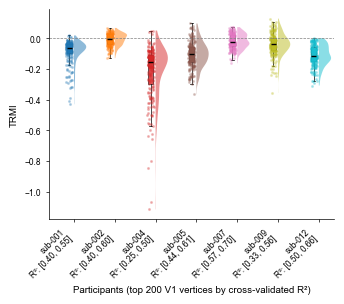

In [8]:
# plot the distribution of surprise ratios for all subjects in one figure
fig, ax = plt.subplots(figsize=cm_to_inch(9, 8))

n_subs = len(subjects)
positions = np.arange(n_subs)
sub_colors = sample_cmap('tab10', n_subs)
rsq_all_subs = []

for i, (sub, sr) in enumerate(zip(subjects, TRMIs)):
    analysis_result_dir = Path(f"/Users/dionysus/Downloads/data/derivatives/prf_data/{sub}/ses-1/{surprise_analysis_type}")
    fn = f"{sub}_ses-1_space-fsaverage_surprise-viol_rsq.npy"
    rsq_fn = analysis_result_dir / fn
    rsq_sub = np.load(rsq_fn, allow_pickle=True)
    # nans and infs should have been handled during data loading, but just in case:
    rsq_sub[np.isnan(rsq_sub)] = 0
    rsq_sub[np.isinf(rsq_sub)] = 0
    rsq_all_subs.append(rsq_sub)

    # top voxels: V1 mask then highest R²
    rsq_v1 = rsq_sub[roi_indices]
    best_idx_local = np.argsort(rsq_v1)[::-1][:nr_best_voxels]
    best_voxel_indices = roi_indices[best_idx_local]
    valid = sr[best_voxel_indices]
    # valid = valid[(~np.isnan(valid)) & (rsq_sub[best_voxel_indices] >= 0.1)]
    pos = positions[i]

    # Half-violin (right side only)
    parts = ax.violinplot(valid, positions=[pos], showextrema=False, widths=0.6)
    for pc in parts['bodies']:
        m = np.mean(pc.get_paths()[0].vertices[:, 0])
        pc.get_paths()[0].vertices[:, 0] = np.clip(
            pc.get_paths()[0].vertices[:, 0], m, np.inf)
        pc.set_facecolor(sub_colors[i])
        pc.set_edgecolor('none')
        pc.set_alpha(0.5)

    # Box plot (narrow, left side)
    bp = ax.boxplot(valid, positions=[pos - 0.12], widths=0.12,
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color='k', linewidth=1),
                    whiskerprops=dict(linewidth=0.5),
                    capprops=dict(linewidth=0.5),
                    boxprops=dict(facecolor=sub_colors[i], edgecolor='k',
                                linewidth=0.5, alpha=0.8))

    # Jittered strip plot (left side)
    jitter = np.random.default_rng(42).uniform(-0.08, 0.08, size=len(valid))
    ax.scatter(pos - 0.12 + jitter, valid, s=1.5, color=sub_colors[i],
            alpha=0.25, zorder=2, rasterized=True)

# Build x-tick labels with R² range
xlabels = []
for i, sub in enumerate(subjects):
    rsq = rsq_all_subs[i]
    rsq = rsq[roi_indices][np.argsort(rsq[roi_indices])[::-1][:nr_best_voxels]]
    xlabels.append(f"{sub}\nR²: [{rsq.min():.2f}, {rsq.max():.2f}]")

# ax.set_ylim(0.5, 1.5)
ax.set_xticks(positions)
ax.set_xticklabels(xlabels, rotation=xticks_rotation, ha='right')
ax.set_ylabel('TRMI')
ax.set_xlabel('Participants (top 200 V1 vertices by cross-validated R²)')
ax.axhline(0, color='gray', ls='--', lw=0.5)
# ax.set_title('Distribution of TRMI across subjects', fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()
plt.show()
fig.savefig(figure_result_dir / f"group_analysis-{surprise_analysis_type}_space-fsaverage_desc-prf_viz_v1_hq-vertex_TRMI-crossvalidatedrsq.pdf", dpi=600, bbox_inches='tight')